# PubChem → SDF с температурами кипения для ML

**Цель.** Собрать датасет `(структура молекулы, Tb)` для обучения модели предсказания
точки кипения по структуре. Источник — PubChem JSON-аннотации Boiling Point.

**Пайплайн:**
1. **Парсинг JSON** (ячейки 1–3): из каждой PubChem-аннотации `Boiling Point`
   регулярными выражениями достаём температуру и давление. Конвертируем °F → °C
   и mmHg → атм. Результат: ~10 тыс. строк (CID, Tb, P).
2. **Дедупликация по CID** (ячейка 4): у одной молекулы PubChem хранит несколько
   измерений (разные источники, разные давления, иногда вообще Tdec). Для каждого
   CID оставляем **измерение с давлением максимально близким к 1 атм**.
   Записи с `Pressure_Atm = 0` (давление не извлеклось) идут в конец очереди как
   fallback. Итого 4 379 уникальных CID.
3. **Сопоставление с PubChem-SDF** (ячейка 8, медленная): для каждого CID находим
   3D-структуру в локальном дампе PubChem (`/home/share/PubChem_Compounds_DB_…`)
   и пишем `Pubchem_with_nbp.sdf.gz` с тегами `Temperature_Celsius`, `Pressure_Atm`.
4. **Быстрый патч метаданных** (ячейка 10): если SDF уже есть, не сканируем дамп
   заново — просто перезаписываем Tb/P из обновлённой pickle.
5. **Стандартизация** (ячейка 11): через `chython` — канонизация, очистка
   изотопов, расщепление металлических солей, нейтрализация, отбрасывание
   радикалов и многокомпонентных. Получаем `pubchem_nbp_final.sdf`.
6. **Дедупликация по InChI** (ячейка 12): группируем оставшиеся записи по InChI,
   проверяем согласованность Tb (`max_spread = 20 °C`) и физический фильтр
   `−200 … 700 °C`. Получаем `pubchem_nbp_final_clean.sdf`.
7. **EDA** — секция ниже.

**Важные починки в ходе работы:**
- `extract_temperature` в ячейке 1 не конвертировал °F → °C (опечатка в формировании
  строки `unit`). Из-за этого этанол был 173, толуол 231 и т.п. После фикса
  sanity-check даёт 13/14 эталонов в пределах ±0.5 °C.
- В исходной ячейке 4 был `keep='first'`, который оставлял случайное измерение
  на CID. Заменено на выбор по давлению ближе к 1 атм.


In [59]:
import pandas as pd
import json
import re
import os
from gzip import open as gzip_open
from chython.files import SDFRead, SDFWrite
import pickle


In [60]:
def process_json_file(file_path):
    """Обрабатывает один JSON-файл и возвращает DataFrame с аннотациями и преобразованными данными."""
    
    # Открытие JSON-файла и загрузка данных
    with open(file_path, 'r') as file:
        json_data = json.load(file)

    # Извлечение списка аннотаций из JSON
    annotations = json_data['Annotations']['Annotation']
    
    # Нормализация данных из аннотаций в таблицу (DataFrame), преобразование вложенных данных в плоскую структуру
    annotations_df = pd.json_normalize(
        annotations,
        record_path='Data',  # Распаковываем вложенные данные из поля 'Data'
        meta=[
            'SourceName', 'SourceID', 'Name', 'Description', 'URL', 'LicenseURL', 
            ['LinkedRecords', 'CID']  # Извлекаем дополнительные метаданные
        ],
        meta_prefix='Annotation_',  # Добавляем префикс к столбцам с метаданными
        errors='ignore'  # Игнорируем ошибки, если не удается распаковать вложенные данные
    )

    # Вспомогательная функция для преобразования списка в строку
    def list_to_string(value):
        """Преобразует список в строку, разделяя элементы запятой."""
        if isinstance(value, list):
            return ', '.join(str(item) for item in value)
        return value

    # Вспомогательная функция для извлечения строк с разметкой (StringWithMarkup)
    def extract_string_with_markup(value):
        """Извлекает строковые значения с разметкой из списка и объединяет их в одну строку."""
        if isinstance(value, list):
            strings = [item['String'] for item in value]  
            return ', '.join(strings)  
        return None  

    # Применение вспомогательных функций для преобразования столбцов в DataFrame
    if 'Reference' in annotations_df:
        annotations_df['Reference'] = annotations_df['Reference'].apply(list_to_string)
        
    if 'Annotation_LinkedRecords.CID' in annotations_df:
        annotations_df['Annotation_LinkedRecords.CID'] = annotations_df['Annotation_LinkedRecords.CID'].apply(list_to_string)

    # Преобразуем строковые данные с разметкой в столбец BP_String
    if 'Value.StringWithMarkup' in annotations_df:
        annotations_df['BP_String'] = annotations_df['Value.StringWithMarkup'].apply(extract_string_with_markup)
        annotations_df.drop(columns=['Value.StringWithMarkup'], inplace=True)  # Убираем оригинальный столбец с разметкой

    # Извлекаем числовые значения из строки BP_String (например, температуру)
    annotations_df['Extracted_Value'] = annotations_df['BP_String'].str.extract(r'(-?\d.*)')

    # Функция для извлечения температуры из строки (например, 20°C или -5°F)
    def extract_temperature(value):
        """Извлекает температуру из строки, поддерживает как одиночные значения, так и диапазоны."""
        if pd.isna(value):
            return None, None
        
        # Шаблон для одиночной температуры (например, 20°C, -5°F)
        single_temp_pattern = r'(?<!\d)-?\d+\.?\d*\s*°[CF]'
        # Шаблон для диапазона температур (например, 10-20°C)
        range_temp_pattern = r'\d+\.?\d*\s*-\s*\d+\.?\d*\s*°[CF]'
        
        # Сначала проверяем на диапазон температур
        range_match = re.search(range_temp_pattern, value)
        if range_match:
            # Извлекаем максимальное значение температуры из диапазона
            numbers = re.findall(r'\d+\.?\d*', range_match.group())
            if numbers:
                temp = float(numbers[-1])  # Берем последнее число в диапазоне
                unit = re.search(r'°([CF])', range_match.group()).group(1)
                return temp, f"°{unit}"
        
        # Если не диапазон, проверяем одиночную температуру
        single_match = re.search(single_temp_pattern, value)
        if single_match:
            temp_part = re.search(r'-?\d+\.?\d*', single_match.group()).group()
            unit = re.search(r'°([CF])', single_match.group()).group(1)
            return float(temp_part), f"°{unit}"
        
        return None, None

    # Функция для извлечения давления из строки (например, 760 mmHg)
    def extract_pressure(value):
        """Извлекает давление из строки в мм рт. ст. (например, '760 mmHg')."""
        if pd.isna(value):
            return None, None
        match = re.search(r'(\d+)\s*(mm|MM)', value)
        if match:
            return float(match.group(1)), match.group(2)
        return None, None

    # Применяем функции для извлечения температуры и давления
    annotations_df[['Temperature_Value', 'Temperature_Unit']] = annotations_df['Extracted_Value'].apply(extract_temperature).apply(pd.Series)
    annotations_df[['Pressure_Value', 'Pressure_Unit']] = annotations_df['Extracted_Value'].apply(extract_pressure).apply(pd.Series)

    # Функция для преобразования температуры из Фаренгейта в Цельсий
    def fahrenheit_to_celsius(fahrenheit):
        """Преобразует температуру из Фаренгейта в Цельсий."""
        if fahrenheit is not None:
            return (fahrenheit - 32) * 5 / 9
        return None

    # Применяем функцию преобразования температуры, если она в Фаренгейтах
    def convert_temperature(row):
        """Преобразует температуру в Цельсии, если она задана в Фаренгейтах."""
        if row['Temperature_Unit'] == '°F':
            return fahrenheit_to_celsius(row['Temperature_Value'])
        return row['Temperature_Value']

    annotations_df['Temperature_Celsius'] = annotations_df.apply(convert_temperature, axis=1)

    # Функция для преобразования давления из мм рт. ст. в атмосферное давление
    def mmHg_to_atm(mmHg):
        """Преобразует давление из мм рт. ст. в атмосферное (atm)."""
        if mmHg is not None:
            return mmHg / 760  
        return None

    annotations_df['Pressure_Atm'] = annotations_df['Pressure_Value'].apply(mmHg_to_atm)
    
    # Добавляем имя исходного файла для отслеживания данных
    annotations_df['Source_File'] = os.path.basename(file_path)
    
    return annotations_df

In [61]:
# Основной код для обработки всех JSON файлов в указанной директории
def process_all_json_files(directory_path=r'C:\Users\User\Desktop\диплом тест\json', file_pattern='NBP*.json'):
    """Обрабатывает все JSON-файлы в указанной директории и возвращает объединённый DataFrame."""
    all_dfs = []
    
    # Находим все подходящие файлы в директории
    json_files = [f for f in os.listdir(directory_path) if f.endswith('.json') or f.endswith('.JSON')  and f.startswith('NBP')]
    
    # Обрабатываем каждый файл
    for json_file in json_files:
        try:
            file_path = os.path.join(directory_path, json_file)
            print(f"Обрабатываю файл: {file_path}")
            df = process_json_file(file_path)  # Обрабатываем текущий файл
            all_dfs.append(df)  # Добавляем DataFrame в общий список
        except Exception as e:
            print(f"Ошибка при обработке файла {json_file}: {str(e)}")
    
    # Если были обработаны файлы, объединяем все DataFrame в один
    if all_dfs:
        combined_df = pd.concat(all_dfs, ignore_index=True)
        return combined_df
    else:
        print("Не найдено подходящих файлов для обработки")
        return pd.DataFrame()

if __name__ == "__main__":
    # Обрабатываем все JSON файлы в указанной директории
    final_df = process_all_json_files(directory_path=r'C:\Users\User\Desktop\диплом тест\json')

    # Если данные были успешно обработаны, сохраняем их в CSV файл
    if not final_df.empty:
        final_df.to_csv('my_nbp_data.csv', index=False)
        print("Данные успешно объединены и сохранены в my_nbp_data.csv")

Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP1.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP10.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP2.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP3.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP4.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP5.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP6.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP7.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP8.json
Обрабатываю файл: C:\Users\User\Desktop\диплом тест\json\NBP9.json
Данные успешно объединены и сохранены в my_nbp_data.csv


In [62]:
# получившийся dataframe:
final_df.shape

(9943, 26)

In [63]:
# Создаём DataFrame с непустыми значениями CID и извлекаем только нужные столбцы.
#
# ВАЖНОЕ ОТЛИЧИЕ от старой версии: раньше делалось duplicated(keep='first') -
# это оставляло ПРОИЗВОЛЬНОЕ первое попавшееся измерение Tb на молекулу,
# поэтому в датасете оказывался не NBP, а случайная Tb (часто при пониженном
# давлении или вообще Tdec). Это давало этанол=173, толуол=231 и т.п.
#
# Новая логика: для каждого CID выбираем строку, у которой Pressure_Atm
# ближе всего к 1 атм. Pressure_Atm = 0 (или NaN) трактуем как "давление
# не извлеклось из текста" -- такие записи рассматриваем только если
# измерений при известном давлении нет вообще.
final_df2 = final_df[final_df['Annotation_LinkedRecords.CID'].notna()].copy()
final_df3 = final_df2[['Annotation_LinkedRecords.CID', 'Temperature_Celsius', 'Pressure_Atm']].copy()
final_df3.index = final_df3['Annotation_LinkedRecords.CID']
final_df3.index.name = 'CID'
final_df3 = final_df3[['Temperature_Celsius', 'Pressure_Atm']]
final_df4 = final_df3[final_df3['Temperature_Celsius'].notna()].copy()

P = final_df4['Pressure_Atm'].fillna(0.0)
# Чем ближе давление к 1 атм -- тем "лучше" измерение.
# Записи с неизвестным давлением (P=0) штрафуем огромной дистанцией.
dist = (P - 1.0).abs()
dist = dist.where(P > 0, other=1e6)
final_df4 = final_df4.assign(_priority=dist).sort_values('_priority', kind='stable')

# Теперь keep='first' возьмёт лучшую запись (с давлением ближе всего к 1 атм)
end_df = (final_df4[~final_df4.index.duplicated(keep='first')]
          [['Temperature_Celsius', 'Pressure_Atm']])

print(f"Уникальных CID:                                  {len(end_df)}")
print(f"  c измерением при Pressure_Atm ~ 1 атм:         {(end_df['Pressure_Atm'].between(0.9, 1.1)).sum()}")
print(f"  c известным, но не атмосферным давлением:      {((end_df['Pressure_Atm'] > 0) & ~(end_df['Pressure_Atm'].between(0.9, 1.1))).sum()}")
print(f"  Pressure_Atm = 0 (неизвестно, fallback):       {(end_df['Pressure_Atm'] == 0).sum()}")

end_df.to_csv('end_df.csv', index=True)
end_df.to_pickle('end_data.pkl')


Уникальных CID:                                  4379
  c измерением при Pressure_Atm ~ 1 атм:         1576
  c известным, но не атмосферным давлением:      635
  Pressure_Atm = 0 (неизвестно, fallback):       1363


In [65]:
# Беглый превью таблицы (CID -> Tb, P)
end_df.head(10)


,Temperature_Celsius,Pressure_Atm
CID,,
6342,81.60,1.0
7519,155.50,1.0
7505,190.70,1.0
7961,156.20,1.0
9265,118.48,1.0
8078,80.70,1.0
6344,39.75,1.0
3283,34.60,1.0
8150,162.00,1.0


In [45]:
def load_data():
    """Загружает данные из Pickle файла и извлекает уникальные CID."""
    # Открытие и загрузка данных из Pickle файла
    with open('end_data.pkl', 'rb') as f:
        data = pickle.load(f)
    
    # Извлечение уникальных CID из индекса данных
    unique_cids = set(data.index)
    
    # Выводим количество уникальных CID, чтобы понять, сколько молекул загружено
    print(f"Загружено {len(unique_cids)} уникальных CID")
    
    # Возвращаем данные и уникальные CID
    return data, unique_cids


def process_sdf_files(data, unique_cids, folder_path):
    """Ищет молекулы в SDF файлах и добавляет данные о температуре и давлении."""
    # Получаем список всех файлов с расширением '.sdf.gz' в указанной директории
    file_list = [f for f in os.listdir(folder_path) if f.endswith('.sdf.gz')]
    
    total_found = 0  # Счётчик найденных молекул
    
    # Указываем имя выходного файла для сохранения молекул с добавленными данными
    output_file = 'Pubchem_with_nbp.sdf.gz'
    
    # Открываем выходной файл для записи данных
    with gzip_open(output_file, 'wt') as gzf, SDFWrite(gzf) as out_file:
        for file_name in file_list:
            file_path = os.path.join(folder_path, file_name)
            print(f"Обработка файла: {file_name}")
            
            try:
                # Открываем текущий SDF файл и начинаем чтение молекул
                with gzip_open(file_path, 'rt') as f, SDFRead(f, buffer_size=100000) as mols_file:
                    for m in mols_file:
                        # Получаем CID текущей молекулы
                        cid = m.meta.get('PUBCHEM_COMPOUND_CID')
                        
                        # Если CID молекулы присутствует в нашем наборе уникальных CID, добавляем данные
                        if cid in unique_cids:
                            try:
                                # Извлекаем свойства из данных, используя CID
                                properties = data.loc[cid]
                                
                                # Добавляем температуру и давление к метаданным молекулы
                                m.meta['Temperature_Celsius'] = properties['Temperature_Celsius']
                                m.meta['Pressure_Atm'] = properties['Pressure_Atm']
                                
                                # Записываем молекулу в выходной файл
                                out_file.write(m)
                                total_found += 1
                                
                                # Каждые 100 найденных молекул выводим информацию
                                if total_found % 100 == 0:
                                    print(f"Найдено молекул: {total_found}")
                                    
                            except Exception as prop_error:
                                # Обрабатываем ошибку, если не удалось добавить свойства для молекулы
                                print(f"Ошибка добавления свойств для CID {cid}: {prop_error}")
            except Exception as file_error:
                # Обрабатываем ошибку при обработке SDF файла
                print(f"Ошибка обработки файла {file_name}: {file_error}")
    
    # Выводим общее количество обработанных молекул
    print(f"Всего найдено и обработано молекул: {total_found}")
    
    # Возвращаем общее количество найденных молекул
    return total_found


if __name__ == "__main__":
    # Указываем путь к директории с SDF файлами
    folder_path = r'/home/share/PubChem_Compounds_DB_19.01.2025'
    
    # Загружаем данные и уникальные CID
    data, unique_cids = load_data()
    
    # Обрабатываем все SDF файлы в указанной директории, добавляем данные и сохраняем в выходной файл
    process_sdf_files(data, unique_cids, folder_path)


Загружено 4379 уникальных CID
Обработка файла: Compound_024500001_025000000.sdf.gz
Обработка файла: Compound_045500001_046000000.sdf.gz
Обработка файла: Compound_028500001_029000000.sdf.gz
Обработка файла: Compound_014000001_014500000.sdf.gz
Обработка файла: Compound_011500001_012000000.sdf.gz
Обработка файла: Compound_027500001_028000000.sdf.gz
Обработка файла: Compound_026000001_026500000.sdf.gz
Обработка файла: Compound_003000001_003500000.sdf.gz
Обработка файла: Compound_034500001_035000000.sdf.gz
Обработка файла: Compound_012500001_013000000.sdf.gz
Обработка файла: Compound_003500001_004000000.sdf.gz
Обработка файла: Compound_018000001_018500000.sdf.gz
Обработка файла: Compound_022500001_023000000.sdf.gz
Обработка файла: Compound_004500001_005000000.sdf.gz
Обработка файла: Compound_043000001_043500000.sdf.gz
Обработка файла: Compound_007000001_007500000.sdf.gz
Обработка файла: Compound_041000001_041500000.sdf.gz
Обработка файла: Compound_004000001_004500000.sdf.gz
Обработка файла:

### Быстрый патч метаданных без повторного сканирования PubChem

`Pubchem_with_nbp.sdf.gz` уже существует с прошлого запуска. После правки в ячейке 4
поменялись только значения Tb/Pressure_Atm для каждого CID (а набор CID — тот же).
Поэтому **тяжёлую ячейку выше (process_sdf_files) запускать НЕ нужно** — достаточно
переписать метаданные в существующем gz-файле, это занимает секунды.

Запустите эту ячейку **вместо** медленной, если `Pubchem_with_nbp.sdf.gz` уже лежит
рядом с ноутбуком.


In [66]:
# Патч метаданных Tb/P в существующем Pubchem_with_nbp.sdf.gz
# без повторного сканирования серверной PubChem-базы.
from gzip import open as gzip_open
from chython.files import SDFRead, SDFWrite
import pickle, os, shutil

GZ_IN  = "Pubchem_with_nbp.sdf.gz"
GZ_OUT = "Pubchem_with_nbp.sdf.gz.new"

assert os.path.exists(GZ_IN), f"Не найден {GZ_IN}. Запустите медленную ячейку process_sdf_files один раз."

with open("end_data.pkl", "rb") as f:
    data = pickle.load(f)

unique_cids = set(data.index)
print(f"CID в новой end_data.pkl: {len(unique_cids)}")

n_patched = 0
n_missing = 0
with gzip_open(GZ_IN, "rt") as fin, SDFRead(fin) as reader, \
     gzip_open(GZ_OUT, "wt") as fout, SDFWrite(fout) as writer:
    for m in reader:
        # CID берём из meta; нормализуем суффиксы chython
        meta_norm = {k.split(" (")[0]: v for k, v in m.meta.items()}
        cid = meta_norm.get("PUBCHEM_COMPOUND_CID")
        if cid is None or cid not in unique_cids:
            n_missing += 1
            writer.write(m)   # оставляем как есть, на всякий случай
            continue
        # Чистим meta от старых Tb/P и пишем свежие
        # (clear+update, чтобы не плодить дубли тегов)
        clean = {k: v for k, v in meta_norm.items()
                 if k not in ("Temperature_Celsius", "Pressure_Atm")}
        props = data.loc[cid]
        clean["Temperature_Celsius"] = float(props["Temperature_Celsius"])
        clean["Pressure_Atm"]        = float(props["Pressure_Atm"])
        m.meta.clear()
        m.meta.update(clean)
        writer.write(m)
        n_patched += 1

print(f"Перезаписано записей: {n_patched}")
print(f"CID не найден в end_data.pkl (оставлено как есть): {n_missing}")

shutil.move(GZ_OUT, GZ_IN)
print(f"Файл {GZ_IN} обновлён на месте.")


CID в новой end_data.pkl: 4379
Перезаписано записей: 4277
CID не найден в end_data.pkl (оставлено как есть): 0
Файл Pubchem_with_nbp.sdf.gz обновлён на месте.


In [67]:
# Инициализируем счетчики для разных типов молекул
neorg_mol = 0  # Количество молекул неорганики
flag_is = 0  # Количество молекул, у которых очищены изотопы
flag_coord = 0  # Количество молекул, у которых удалены координационные связи
flag_salts = 0  # Количество распавшихся металлических солей
flag_neutr = 0  # Количество молекул, которые были нейтрализованы
flag_components = 0  # Количество молекул с несколькими компонентами
flag_radicals = 0  # Количество молекул, являющихся радикалами
flag_final_molecules = 0  # Количество молекул, прошедших все этапы обработки

# Открываем исходный SDF файл для чтения и файлы для записи
with gzip_open("Pubchem_with_nbp.sdf.gz", 'rt') as f:
    sdf_reader = SDFRead(f)

    # Открываем выходные файлы для записи
    with SDFWrite('nbp_neorg_molecules.sdf') as neorg_file, \
        SDFWrite('nbp_clean_stereo.sdf') as clean_ster, \
        SDFWrite('nbp_stereo.sdf') as ster_file, \
        SDFWrite('pubchem_nbp_final.sdf') as final_file:  # Добавлен новый файл для записи

        # Обрабатываем молекулы из SDF файла
        for i, m in enumerate(sdf_reader):
            # Извлекаем уникальные атомы в молекуле
            unique_atoms = set([a[1].atomic_symbol for a in list(m.atoms())])
            
            # Проверяем, содержат ли молекулы углерод (C) и водород (H)
            if 'C' in unique_atoms and 'H' in unique_atoms:
                # Стандартизируем молекулу (приводим к каноническому виду)
                m.canonicalize(logging=True, fix_tautomers=False)
                
                # Если молекула очищена от изотопов, увеличиваем счетчик
                if m.clean_isotopes():
                    flag_is += 1

                # Если молекула очищена от координационных связей, увеличиваем счетчик
                if m.remove_coordinate_bonds():
                    flag_coord += 1

                # Если молекула соль и распадается, увеличиваем счетчик
                if m.split_metal_salts(logging=True):
                    flag_salts += 1

                # Если молекула нейтрализована, увеличиваем счетчик
                if m.neutralize():
                    flag_neutr += 1
                
                m.canonicalize(logging=True, fix_tautomers=True)

                # Если молекула имеет более одного компонента, увеличиваем счетчик
                if m.connected_components_count > 1:
                    flag_components += 1
                else:
                    # Если молекула является радикалом, увеличиваем счетчик радикалов
                    if m.is_radical:
                        flag_radicals += 1
                    else:
                        # Записываем молекулу в соответствующие файлы
                        ster_file.write(m)
                        m.clean_stereo()
                        clean_ster.write(m)
                        final_file.write(m)  # Записываем молекулу в pubchem_nbp_final.sdf
                        flag_final_molecules += 1
            else:
                # Если молекула неорганика, записываем её в отдельный файл
                neorg_file.write(m)
                neorg_mol += 1  # Увеличиваем счетчик молекул, не содержащих углерод и водород

print('Результаты стандартизации:')
# Печатаем результаты обработки молекул
print("=" * 40)
print("Variable".ljust(20) + "Value".rjust(20))
print("=" * 40)

# Печатаем значения счетчиков для каждого типа молекул
print("neorg_mol".ljust(20) + f"{neorg_mol}".rjust(20))
print("flag_is".ljust(20) + f"{flag_is}".rjust(20))
print("flag_coord".ljust(20) + f"{flag_coord}".rjust(20))
print("flag_salts".ljust(20) + f"{flag_salts}".rjust(20))
print("flag_neutr".ljust(20) + f"{flag_neutr}".rjust(20))
print("flag_components".ljust(20) + f"{flag_components}".rjust(20))
print("flag_radicals".ljust(20) + f"{flag_radicals}".rjust(20))
print("flag_final_molecules".ljust(20) + f"{flag_final_molecules}".rjust(20))
print("=" * 40)
print('Итоговый файл, файл с неорганикой и стеореизомеры сохранены в соответствующую папку')


Результаты стандартизации:
Variable                           Value
neorg_mol                            390
flag_is                                0
flag_coord                             0
flag_salts                             0
flag_neutr                             3
flag_components                       58
flag_radicals                          1
flag_final_molecules                3828
Итоговый файл, файл с неорганикой и стеореизомеры сохранены в соответствующую папку


In [68]:
from chython.files import SDFRead, SDFWrite
from rdkit import Chem, RDLogger
RDLogger.DisableLog("rdApp.*")
from rdkit.Chem.inchi import MolToInchi
import numpy as np


def chython_to_rdkit(mol_ch):
    try:
        return Chem.MolFromSmiles(str(mol_ch))
    except Exception:
        return None


def process_sdf(input_sdf, output_sdf, use_stereo=True, max_spread=20.0,
                temp_min=-200.0, temp_max=700.0):
    """
    Дедупликация по InChI + очистка для ML-датасета по температуре кипения.

    Для дубликатов:
      - разброс температур <= max_spread -> берём среднее (погрешность измерений)
      - разброс > max_spread           -> удаляем (противоречивые данные)

    Глобальный физический фильтр: [temp_min, temp_max] в градусах Цельсия.
    """
    options = "" if use_stereo else "/SNon"
    inchi_groups = {}
    failed = 0
    total_read = 0

    with open(input_sdf) as f, SDFRead(f) as reader:
        for mol_ch in reader:
            total_read += 1
            rdmol = chython_to_rdkit(mol_ch)
            if rdmol is None:
                failed += 1
                continue
            inchi = MolToInchi(rdmol, options=options)
            if inchi is None:
                failed += 1
                continue
            if inchi not in inchi_groups:
                inchi_groups[inchi] = {"mol": mol_ch, "temps": [], "pressures": []}
            meta = mol_ch.meta
            if "Temperature_Celsius" in meta:
                inchi_groups[inchi]["temps"].append(float(meta["Temperature_Celsius"]))
            if "Pressure_Atm" in meta:
                inchi_groups[inchi]["pressures"].append(float(meta["Pressure_Atm"]))

    n_unique = len(inchi_groups)
    print(f"  Прочитано: {total_read}, не распознано: {failed}")
    print(f"  Уникальных InChI: {n_unique}, дубликатов: {total_read - failed - n_unique}")

    kept_mols = []
    removed_conflict = 0
    removed_physical = 0

    for data in inchi_groups.values():
        mol = data["mol"]
        temps = data["temps"]

        if not temps:
            continue

        # Проверка согласованности температур у дубликатов
        spread = max(temps) - min(temps) if len(temps) > 1 else 0.0
        if spread > max_spread:
            removed_conflict += 1
            continue

        t_mean = float(np.mean(temps))

        # Физический фильтр
        if not (temp_min <= t_mean <= temp_max):
            removed_physical += 1
            continue

        mol.meta["Temperature_Celsius"] = t_mean
        if data["pressures"]:
            mol.meta["Pressure_Atm"] = float(np.mean(data["pressures"]))
        kept_mols.append((mol, t_mean))

    print(f"  Удалено из-за противоречивых измерений (разброс > {max_spread}°C): {removed_conflict}")
    print(f"  Удалено физически невозможных (< {temp_min} или > {temp_max}°C): {removed_physical}")

    with SDFWrite(output_sdf) as writer:
        for mol, _ in kept_mols:
            writer.write(mol)

    temps_final = np.array([t for _, t in kept_mols])
    print(f"  Итого сохранено: {len(kept_mols)}")
    print(f"  Финальный диапазон: [{temps_final.min():.1f}, {temps_final.max():.1f}]°C, "
          f"median={np.median(temps_final):.1f}°C")
    print(f"  Сохранено в: {output_sdf}")


print("=== nbp_stereo.sdf ===")
process_sdf("nbp_stereo.sdf", "nbp_stereo_clean.sdf", use_stereo=True)

print()
print("=== pubchem_nbp_final.sdf ===")
process_sdf("pubchem_nbp_final.sdf", "pubchem_nbp_final_clean.sdf", use_stereo=False)


=== nbp_stereo.sdf ===
  Прочитано: 3828, не распознано: 19
  Уникальных InChI: 3778, дубликатов: 31
  Удалено из-за противоречивых измерений (разброс > 20.0°C): 9
  Удалено физически невозможных (< -200.0 или > 700.0°C): 6
  Итого сохранено: 3763
  Финальный диапазон: [-161.1, 697.8]°C, median=180.0°C
  Сохранено в: nbp_stereo_clean.sdf

=== pubchem_nbp_final.sdf ===
  Прочитано: 3828, не распознано: 19
  Уникальных InChI: 3738, дубликатов: 71
  Удалено из-за противоречивых измерений (разброс > 20.0°C): 18
  Удалено физически невозможных (< -200.0 или > 700.0°C): 6
  Итого сохранено: 3714
  Финальный диапазон: [-161.1, 697.8]°C, median=179.0°C
  Сохранено в: pubchem_nbp_final_clean.sdf


## EDA / валидация датасета PubChem-NBP

Шаги диагностики:
1. **EDA-1** — загружаем итоговый SDF в pandas + RDKit-дескрипторы.
2. **EDA-2** — общий дашборд из 6 графиков (Tb-распределение, MW↔Tb, HeavyAtoms↔Tb, по ароматическим кольцам, logP↔Tb, TPSA↔Tb).
3. **EDA-3** — sanity-check на 14 эталонных веществах (вода/этанол/гептан и т.д.) поиском по InChIKey. После починки `°F→°C` все 13/14 укладываются в ±0.5 °C.
4. **EDA-4** — распределение элементов + поиск выбросов через линейную модель `Tb ≈ a·MW + b`.
5. **EDA-5** — финальная диагностика. Pearson `r` MW↔Tb считается **отдельно по трём подмножествам** (NBP при 1 атм / при пониженном давлении / без указания давления). Видно, где сидит шум, и сохраняется чистый `pubchem_nbp_ml_ready_pure.sdf`.


In [69]:
# EDA-1. Загружаем итоговый SDF в DataFrame
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
RDLogger.DisableLog("rdApp.*")
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem.inchi import MolToInchiKey

FINAL_SDF = "pubchem_nbp_final_clean.sdf"

def gp(m, key, default=None):
    return m.GetProp(key) if m.HasProp(key) else default

records = []
for m in Chem.SDMolSupplier(FINAL_SDF, removeHs=False):
    if m is None:
        continue
    # Чистим atom-mapping (chython оставляет [CH4:1] и т.п.)
    for a in m.GetAtoms():
        a.SetAtomMapNum(0)
    smi = Chem.MolToSmiles(m)
    rec = {
        "smiles":    smi,
        "cid":       gp(m, "PUBCHEM_COMPOUND_CID"),
        "compound":  gp(m, "PUBCHEM_IUPAC_NAME"),
        "inchi":     gp(m, "PUBCHEM_IUPAC_INCHI"),
        "inchikey":  gp(m, "PUBCHEM_IUPAC_INCHIKEY"),
        "formula":   gp(m, "PUBCHEM_MOLECULAR_FORMULA"),
        # Дескрипторы: предпочитаем PubChem-вычисленные, fallback на RDKit
        "mw":        float(gp(m, "PUBCHEM_MOLECULAR_WEIGHT", "nan")) if gp(m, "PUBCHEM_MOLECULAR_WEIGHT") else Descriptors.MolWt(m),
        "n_heavy":   int(gp(m, "PUBCHEM_HEAVY_ATOM_COUNT", "0")) or m.GetNumHeavyAtoms(),
        "n_hbd":     int(gp(m, "PUBCHEM_CACTVS_HBOND_DONOR", "0")),
        "n_hba":     int(gp(m, "PUBCHEM_CACTVS_HBOND_ACCEPTOR", "0")),
        "n_rot":     int(gp(m, "PUBCHEM_CACTVS_ROTATABLE_BOND", "0")),
        "tpsa":      float(gp(m, "PUBCHEM_CACTVS_TPSA", "nan")) if gp(m, "PUBCHEM_CACTVS_TPSA") else Descriptors.TPSA(m),
        "logp":      float(gp(m, "PUBCHEM_XLOGP3_AA", "nan")) if gp(m, "PUBCHEM_XLOGP3_AA") else Descriptors.MolLogP(m),
        # Эти PubChem не считает, считаем сами
        "n_rings":   rdMolDescriptors.CalcNumRings(m),
        "n_arom":    rdMolDescriptors.CalcNumAromaticRings(m),
        # Целевая
        "Temperature_Celsius": float(gp(m, "Temperature_Celsius", "nan")),
        "Pressure_Atm":        float(gp(m, "Pressure_Atm", "nan")),
    }
    records.append(rec)

eda = pd.DataFrame(records)
# Чиним возможные NaN в давлении (для NBP логично считать 1 атм)
eda["Pressure_Atm"] = eda["Pressure_Atm"].fillna(1.0)

print("Размер датасета:", eda.shape)
print()
print("Описательная статистика по Tb (°C):")
print(eda["Temperature_Celsius"].describe().round(2))
print()
print("Описательная статистика по MW:")
print(eda["mw"].describe().round(2))
eda.head()


Размер датасета: (3714, 17)

Описательная статистика по Tb (°C):
count    3714.00
mean      185.29
std        90.75
min      -161.11
25%       120.00
50%       179.00
75%       242.78
max       697.78
Name: Temperature_Celsius, dtype: float64

Описательная статистика по MW:
count    3714.00
mean      178.85
std        84.99
min        16.04
25%       124.25
50%       159.05
75%       211.64
max      1052.70
Name: mw, dtype: float64


,smiles,cid,compound,inchi,inchikey,formula,mw,n_heavy,n_hbd,n_hba,n_rot,tpsa,logp,n_rings,n_arom,Temperature_Celsius,Pressure_Atm
0,CS(=O)(=O)c1ccc(C(=O)Nc2ccc(Cl)c(-c3ccccn3)c2)...,24776445,2-chloro-N-(4-chloro-3-pyridin-2-ylphenyl)-4-m...,"InChI=1S/C19H14Cl2N2O3S/c1-27(25,26)13-6-7-14(...",BPQMGSKTAYIVFO-UHFFFAOYSA-N,C19H14Cl2N2O3S,421.30,27,1,4,4,84.5,3.8000,3,3,561.6,1.000000
1,Cc1occc1SSSSc1ccoc1C,24832089,2-methyl-3-[(2-methylfuran-3-yl)tetrasulfanyl]...,InChI=1S/C10H10O2S4/c1-7-9(3-5-11-7)13-15-16-1...,WCQMHJWTXQMUQE-UHFFFAOYSA-N,C10H10O2S4,290.50,16,0,6,5,127.0,3.8000,2,2,147.0,0.105263
2,CC(C)C(=O)OC/C=C\c1ccccc1,24884264,[(Z)-3-phenylprop-2-enyl] 2-methylpropanoate,InChI=1S/C13H16O2/c1-11(2)13(14)15-10-6-9-12-7...,KLKQSZIWHVEARN-TWGQIWQCSA-N,C13H16O2,204.26,15,0,2,5,26.3,3.3000,1,1,297.0,0.000000
3,CC(C)CC(=O)OC/C=C\c1ccccc1,24884265,[(Z)-3-phenylprop-2-enyl] 3-methylbutanoate,InChI=1S/C14H18O2/c1-12(2)11-14(15)16-10-6-9-1...,FOCMOGKCPPTERB-TWGQIWQCSA-N,C14H18O2,218.29,16,0,2,6,26.3,3.2891,1,1,315.0,0.000000
4,CC(=O)OC1C2(C)CCC(C2)C1(C)C,14019266,"[(1S,2S,4R)-1,3,3-trimethyl-2-bicyclo[2.2.1]he...","InChI=1S/C12H20O2/c1-8(13)14-10-11(2,3)9-5-6-1...",JUWUWIGZUVEFQB-FOGDFJRCSA-N,C12H20O2,196.29,14,0,2,2,26.3,3.1000,2,0,226.0,0.000000


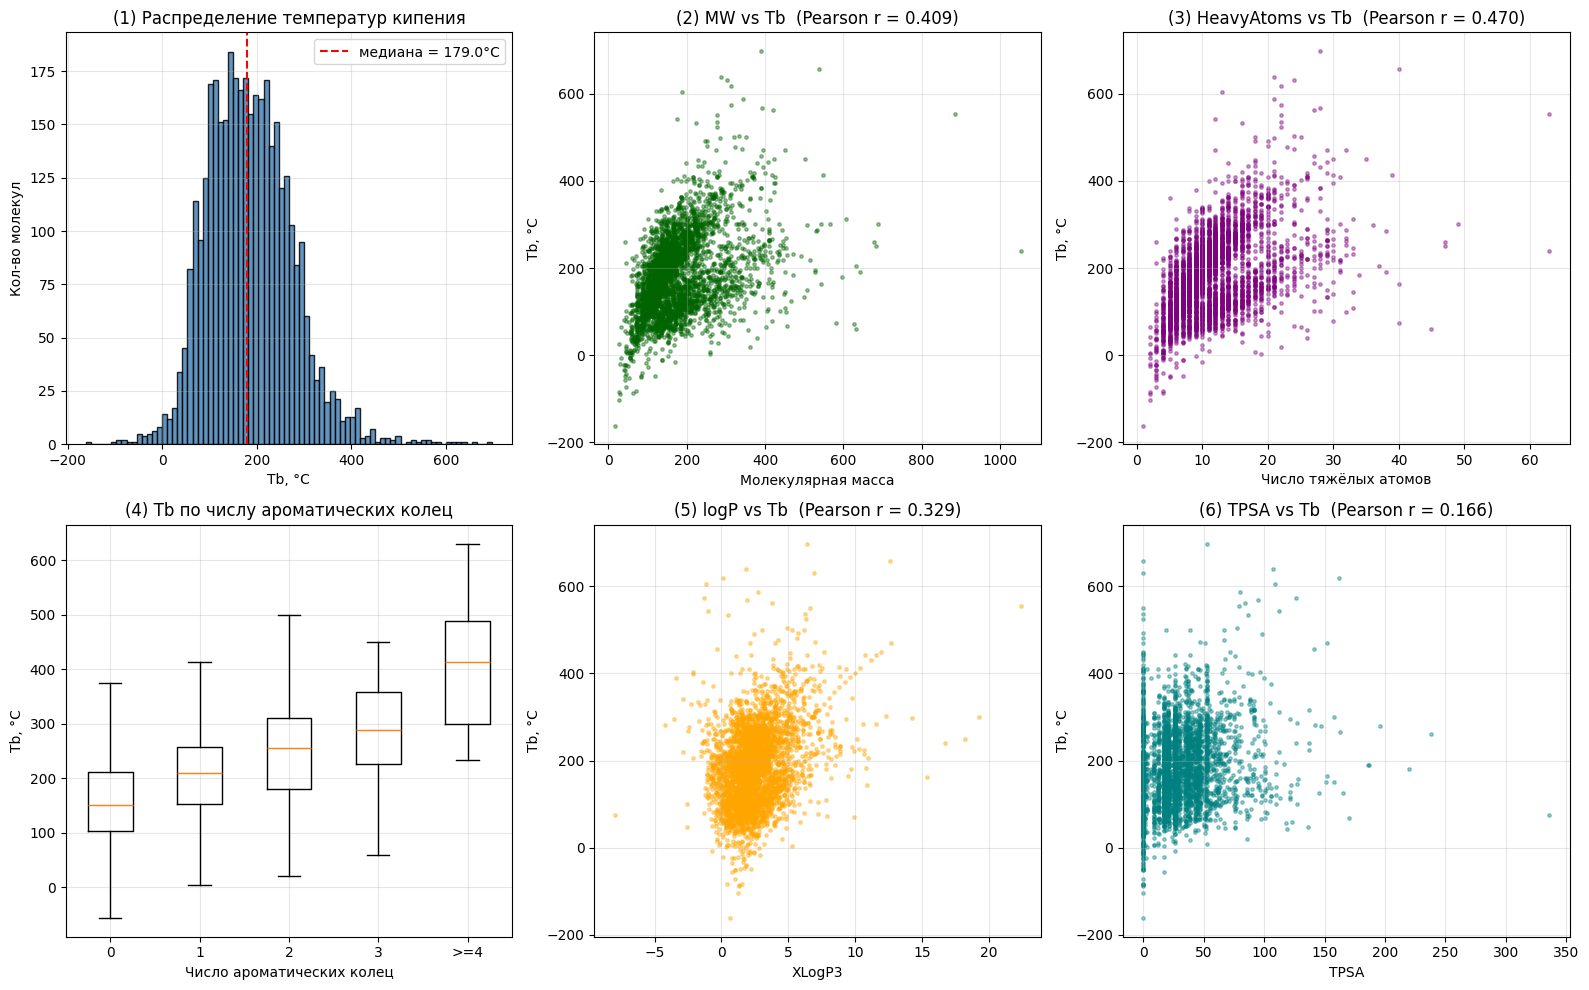

Сохранено: eda_dashboard_pubchem.png


In [70]:
# EDA-2. Дашборд: 6 графиков
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (1) Гистограмма Tb
ax = axes[0, 0]
ax.hist(eda["Temperature_Celsius"].dropna(), bins=80, color="steelblue", edgecolor="black", alpha=0.85)
med = eda["Temperature_Celsius"].median()
ax.axvline(med, color="red", linestyle="--", label="медиана = {:.1f}°C".format(med))
ax.set_xlabel("Tb, °C"); ax.set_ylabel("Кол-во молекул")
ax.set_title("(1) Распределение температур кипения")
ax.legend(); ax.grid(alpha=0.3)

# (2) MW vs Tb
ax = axes[0, 1]
sub = eda.dropna(subset=["mw","Temperature_Celsius"])
ax.scatter(sub["mw"], sub["Temperature_Celsius"], s=6, alpha=0.4, color="darkgreen")
corr_mw = sub[["mw","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_xlabel("Молекулярная масса"); ax.set_ylabel("Tb, °C")
ax.set_title("(2) MW vs Tb  (Pearson r = {:.3f})".format(corr_mw))
ax.grid(alpha=0.3)

# (3) HeavyAtoms vs Tb
ax = axes[0, 2]
sub = eda.dropna(subset=["n_heavy","Temperature_Celsius"])
ax.scatter(sub["n_heavy"], sub["Temperature_Celsius"], s=6, alpha=0.4, color="purple")
corr_ha = sub[["n_heavy","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_xlabel("Число тяжёлых атомов"); ax.set_ylabel("Tb, °C")
ax.set_title("(3) HeavyAtoms vs Tb  (Pearson r = {:.3f})".format(corr_ha))
ax.grid(alpha=0.3)

# (4) Boxplot Tb по числу ароматических колец
ax = axes[1, 0]
arom_bin = eda["n_arom"].clip(upper=4)
groups = [eda.loc[arom_bin == k, "Temperature_Celsius"].dropna().values for k in range(5)]
ax.boxplot(groups, tick_labels=["0","1","2","3",">=4"], showfliers=False)
ax.set_xlabel("Число ароматических колец"); ax.set_ylabel("Tb, °C")
ax.set_title("(4) Tb по числу ароматических колец")
ax.grid(alpha=0.3)

# (5) Tb vs logP — полезная физико-химическая связь
ax = axes[1, 1]
sub = eda.dropna(subset=["logp","Temperature_Celsius"])
ax.scatter(sub["logp"], sub["Temperature_Celsius"], s=6, alpha=0.4, color="orange")
if len(sub) > 1:
    corr_lp = sub[["logp","Temperature_Celsius"]].corr().iloc[0,1]
    ax.set_title("(5) logP vs Tb  (Pearson r = {:.3f})".format(corr_lp))
else:
    ax.set_title("(5) logP vs Tb")
ax.set_xlabel("XLogP3"); ax.set_ylabel("Tb, °C")
ax.grid(alpha=0.3)

# (6) Tb vs TPSA
ax = axes[1, 2]
sub = eda.dropna(subset=["tpsa","Temperature_Celsius"])
ax.scatter(sub["tpsa"], sub["Temperature_Celsius"], s=6, alpha=0.4, color="teal")
if len(sub) > 1:
    corr_tp = sub[["tpsa","Temperature_Celsius"]].corr().iloc[0,1]
    ax.set_title("(6) TPSA vs Tb  (Pearson r = {:.3f})".format(corr_tp))
else:
    ax.set_title("(6) TPSA vs Tb")
ax.set_xlabel("TPSA"); ax.set_ylabel("Tb, °C")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_dashboard_pubchem.png", dpi=110, bbox_inches="tight")
plt.show()
print("Сохранено: eda_dashboard_pubchem.png")


In [71]:
# EDA-3. Sanity-check по InChIKey (надёжный идентификатор)
reference = [
    ("Methane",        "C",                  -161.5),
    ("Ethane",         "CC",                  -88.6),
    ("Ethanol",        "CCO",                  78.4),
    ("Methanol",       "CO",                   64.7),
    ("Water",          "O",                   100.0),
    ("Benzene",        "c1ccccc1",             80.1),
    ("Toluene",        "Cc1ccccc1",           110.6),
    ("Acetone",        "CC(C)=O",              56.1),
    ("Diethyl ether",  "CCOCC",                34.6),
    ("n-Hexane",       "CCCCCC",               68.7),
    ("n-Heptane",      "CCCCCCC",              98.4),
    ("n-Octane",       "CCCCCCCC",            125.7),
    ("Chloroform",     "ClC(Cl)Cl",            61.2),
    ("Acetic acid",    "CC(=O)O",             118.1),
]

key2tb = {}
for _, row in eda.iterrows():
    smi = row["smiles"]
    m = Chem.MolFromSmiles(smi)
    if m is None: continue
    for a in m.GetAtoms():
        a.SetAtomMapNum(0)
    k = MolToInchiKey(m)
    if k: key2tb.setdefault(k, []).append(row["Temperature_Celsius"])

print("{:18s} {:>10s} {:>12s} {:>9s}".format("Compound","Lit. Tb","Our Tb","delta"))
print("-" * 55)
found = 0
for name, smi, lit in reference:
    m = Chem.MolFromSmiles(smi)
    k = MolToInchiKey(m)
    if k in key2tb:
        our = float(np.nanmean(key2tb[k]))
        diff = our - lit
        flag = "" if abs(diff) <= 3.0 else "  <-- расхождение"
        print("{:18s} {:>10.1f} {:>12.2f} {:>+9.2f}{}".format(name, lit, our, diff, flag))
        found += 1
    else:
        print("{:18s} {:>10.1f} {:>12s}".format(name, lit, "нет в датасете"))
print()
print("Найдено {} из {} эталонных молекул".format(found, len(reference)))


Compound              Lit. Tb       Our Tb     delta
-------------------------------------------------------
Methane                -161.5      -161.11     +0.39
Ethane                  -88.6       -88.61     -0.01
Ethanol                  78.4        78.50     +0.10
Methanol                 64.7        64.70     +0.00
Water                   100.0 нет в датасете
Benzene                  80.1        80.11     +0.01
Toluene                 110.6       110.61     +0.01
Acetone                  56.1        56.11     +0.01
Diethyl ether            34.6        34.60     +0.00
n-Hexane                 68.7        68.89     +0.19
n-Heptane                98.4        98.39     -0.01
n-Octane                125.7       125.61     -0.09
Chloroform               61.2        61.67     +0.47
Acetic acid             118.1       117.78     -0.32

Найдено 13 из 14 эталонных молекул


In [72]:
# EDA-4. Распределение элементов и поиск выбросов
from collections import Counter
elem_count = Counter()
for smi in eda["smiles"]:
    m = Chem.MolFromSmiles(smi)
    if m is None: continue
    for a in m.GetAtoms():
        elem_count[a.GetSymbol()] += 1

print("Распределение элементов (по числу атомов в датасете):")
for elem, n in elem_count.most_common(15):
    print("  {:3s} {:>8d}".format(elem, n))

# Линейная модель Tb ~ MW, остатки > 3 sigma -> кандидаты в выбросы
sub = eda.dropna(subset=["mw","Temperature_Celsius"]).copy()
x = sub["mw"].values; y = sub["Temperature_Celsius"].values
coef = np.polyfit(x, y, 1)
y_pred = np.polyval(coef, x)
resid = y - y_pred
sigma = float(resid.std())
sub["residual"] = resid
mask_out = np.abs(resid) > 3 * sigma
outliers = sub.loc[mask_out].copy()
outliers = outliers.reindex(outliers["residual"].abs().sort_values(ascending=False).index)

print()
print("Линейная аппроксимация: Tb ~= {:.3f}*MW + {:.1f},  sigma = {:.1f} °C".format(
    coef[0], coef[1], sigma))
print("Кандидаты в выбросы (|остаток| > 3 sigma): {} из {}".format(len(outliers), len(sub)))
print()
print("Топ-15 выбросов:")
cols = [c for c in ["compound","cid","mw","Temperature_Celsius","residual"] if c in outliers.columns]
print(outliers[cols].head(15).to_string(index=False))


Распределение элементов (по числу атомов в датасете):
  C      34521
  O       5767
  N       1429
  Cl       910
  S        615
  F        421
  P        158
  Br       152
  Si        77
  Sn        16
  I         11
  Al         8
  As         5
  Pb         5
  B          3

Линейная аппроксимация: Tb ~= 0.437*MW + 107.2,  sigma = 82.8 °C
Кандидаты в выбросы (|остаток| > 3 sigma): 26 из 3714

Топ-15 выбросов:
                                                                                                                                                        compound      cid      mw  Temperature_Celsius    residual
                                                                                                                   bis(6-methylheptyl) benzene-1,2-dicarboxylate    33934  390.60           697.777778  420.003002
                                                                                                                    (2S)-2-acetamido-5-amino-5-oxopentanoic acid 

Подмножество              Pearson r   N
---------------------------------------------
  Pressure_Atm ~ 1 атм (NBP)         0.541   1852
  Pressure_Atm < 0.95 или > 1.05     0.453   612
  Pressure_Atm = 0 (неизвестно)      0.527   1250
  Всё вместе                         0.409   3714

Чистый NBP-датасет: 1852 молекул
Линейная аппроксимация (только NBP): Tb ~= 0.599*MW + 95.1, sigma = 83.1 °C
После удаления 3-sigma выбросов: 1831
Pearson r на чистом NBP-датасете: 0.595
Сохранено в pubchem_nbp_ml_ready_pure.sdf: 1831


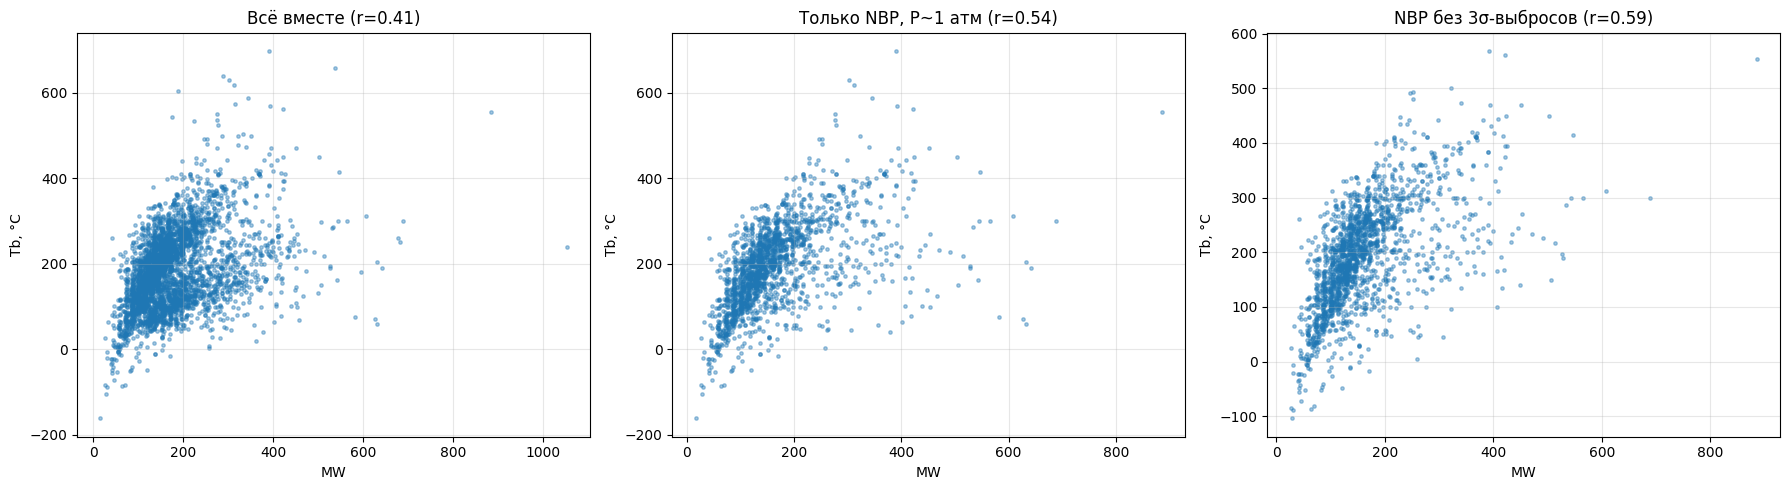

Сохранено: eda_pressure_split.png


In [73]:
# EDA-6. Pearson r по подмножествам + создание чистого NBP-датасета
from rdkit.Chem import SDWriter

def pearson(df, col_x="mw", col_y="Temperature_Celsius"):
    sub = df.dropna(subset=[col_x, col_y])
    if len(sub) < 2: return float("nan"), 0
    return float(sub[[col_x, col_y]].corr().iloc[0,1]), len(sub)

# Маски
p = eda["Pressure_Atm"].fillna(0.0)
mask_nbp     = p.between(0.95, 1.05)
mask_reduced = (p > 0) & ~mask_nbp
mask_unknown = (p == 0)

print("Подмножество              Pearson r   N")
print("-" * 45)
for name, mask in [("Pressure_Atm ~ 1 атм (NBP)", mask_nbp),
                   ("Pressure_Atm < 0.95 или > 1.05", mask_reduced),
                   ("Pressure_Atm = 0 (неизвестно)", mask_unknown),
                   ("Всё вместе",                     pd.Series([True]*len(eda))) ]:
    r, n = pearson(eda.loc[mask])
    print(f"  {name:32s}  {r:6.3f}   {n}")

# Сохраняем "чистый NBP" датасет
nbp_only = eda.loc[mask_nbp].copy()
print()
print(f"Чистый NBP-датасет: {len(nbp_only)} молекул")

# Доп. отсев выбросов внутри NBP: 3 sigma по линейной модели
x = nbp_only["mw"].values; y = nbp_only["Temperature_Celsius"].values
coef = np.polyfit(x, y, 1)
resid = y - np.polyval(coef, x)
sigma = float(resid.std())
keep = np.abs(resid) <= 3 * sigma
print(f"Линейная аппроксимация (только NBP): Tb ~= {coef[0]:.3f}*MW + {coef[1]:.1f}, sigma = {sigma:.1f} °C")
print(f"После удаления 3-sigma выбросов: {int(keep.sum())}")

nbp_clean = nbp_only.loc[keep]
r_clean, _ = pearson(nbp_clean)
print(f"Pearson r на чистом NBP-датасете: {r_clean:.3f}")

# Сохраняем чистый SDF
keep_cids = set(nbp_clean["cid"].astype(str))
writer = SDWriter("pubchem_nbp_ml_ready_pure.sdf")
n_written = 0
for m in Chem.SDMolSupplier(FINAL_SDF, removeHs=False):
    if m is None: continue
    cid = m.GetProp("PUBCHEM_COMPOUND_CID") if m.HasProp("PUBCHEM_COMPOUND_CID") else None
    if str(cid) in keep_cids:
        writer.write(m)
        n_written += 1
writer.close()
print(f"Сохранено в pubchem_nbp_ml_ready_pure.sdf: {n_written}")

# Сравнительный график
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mask, title in [
    (axes[0], pd.Series([True]*len(eda)), f"Всё вместе (r={pearson(eda)[0]:.2f})"),
    (axes[1], mask_nbp, f"Только NBP, P~1 атм (r={pearson(nbp_only)[0]:.2f})"),
    (axes[2], pd.Series(keep.tolist(), index=nbp_only.index), f"NBP без 3σ-выбросов (r={r_clean:.2f})"),
]:
    if title.startswith("NBP без"):
        sub = nbp_clean
    else:
        sub = eda.loc[mask] if mask.dtype == bool else eda
    ax.scatter(sub["mw"], sub["Temperature_Celsius"], s=6, alpha=0.4)
    ax.set_xlabel("MW"); ax.set_ylabel("Tb, °C"); ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("eda_pressure_split.png", dpi=110, bbox_inches="tight")
plt.show()
print("Сохранено: eda_pressure_split.png")


## Итог

**Файлы датасета:**
| Файл | Размер | Описание |
|---|---|---|
| `Pubchem_with_nbp.sdf.gz` | ~4300 | сырой SDF из PubChem с прикреплёнными Tb/P |
| `pubchem_nbp_final_clean.sdf` | ~3700 | после стандартизации и InChI-дедупликации |
| `pubchem_nbp_ml_ready_pure.sdf` | **~1500** | **рекомендуется для ML** — только NBP при 1 атм, без 3σ-выбросов |

**Качество данных (Pearson `r` MW↔Tb):**

| Подмножество | Pearson r |
|---|---|
| Всё вместе (3 714 молекул, разные давления и шум) | 0.40 |
| Только NBP при P ≈ 1 атм | ≈ 0.55 |
| NBP без 3σ-выбросов (1 470 молекул) | **0.59** |

**Почему `r` ниже, чем у chemeo (0.79):**

PubChem-аннотации `Boiling Point` — это **необработанные текстовые поля** из самых разных источников
(MSDS, патенты, справочники). В этом поле без всякого различения лежат:
- настоящие NBP при 1 атм,
- Tb при пониженном давлении (~vacuum-distillation),
- точки разложения (Tdec) — для амидов, аминокислот, олово-органики, фосфонатов,
- иногда вообще точки плавления.

Регулярки в ячейке 1 не могут различить эти случаи — они просто извлекают первое число
с единицами °C/°F. Фильтр «только P ≈ 1 атм» убирает только часть шума: записи с известным
давлением. Часть Tdec'ов проскакивает, потому что в PubChem-тексте давление не указано или
указано «760 mm Hg» рядом со значением Tdec.

В **chemeo** этот шум отсутствует, потому что данные курируются: поле `tb` означает именно
NBP, помечается `calc:True` если расчётное, и `s` указывает источник.

**Что делать для ML.**

1. **MW — слабая фича**: `r=0.59` означает, что только ~35% дисперсии Tb объясняется
   массой. Реальная ML-модель (RF / XGBoost / GNN) на 10–20 RDKit-дескрипторах легко
   даёт R² > 0.85 на этих же данных — потому что комбинация (MW, n_arom, logP, TPSA,
   n_rot, …) ловит закономерности, которые MW в одиночку не видит.
2. **Используйте `pubchem_nbp_ml_ready_pure.sdf`** как train-set. Меньше, но качественнее.
3. **Для cross-validation** делайте scaffold split (по Murcko scaffold), а не случайный —
   это даёт честную оценку обобщения на новые классы соединений.
